# U11 — Dimensionality Reduction: Lab

### Real-world brief: predictive maintenance on factory machines

Each machine streams **24 sensor channels** (temperatures, vibration, current, pressure…). Many of them move together, so the data is high-dimensional but *redundant*. Your job: cut the dimensionality while keeping the signal, so a maintenance model is faster, simpler and easier to visualise.

**Resources provided:** `machine_sensors.csv` (one row per machine reading, 24 sensors + a `condition` label) and `sensor_info.xlsx` (sensor metadata). Keep them beside this notebook (upload them in Colab).

_Phase C — Data Engineering & Preparation._

#objectives

Show why high-dimensional, correlated data needs reduction

Use feature selection (variance, correlation, mutual information) to drop weak columns

Apply PCA: standardise, fit, read explained variance, choose components

Project to 2-D and visualise machine condition

Compare the compressed representation with the original 24 features

#how to use this lab

Worked demo cells teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [ ]:
# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
sensors = [c for c in df.columns if c not in ('machine_id', 'condition')]
print('readings:', df.shape, '| sensors:', len(sensors))
df.head(3)

readings: (2000, 26) | sensors: 24


,machine_id,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,...,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity,condition
0,MX0001,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,...,23.12,23.46,66.89,84.58,61.36,27.83,83.31,415.31,45.07,Normal
1,MX0002,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,...,30.54,25.88,84.32,90.57,71.68,35.50,77.44,414.68,45.11,Warning
2,MX0003,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,...,28.56,26.87,82.34,89.42,64.28,35.80,77.43,415.48,45.13,Warning


#1. The high-dimensional problem

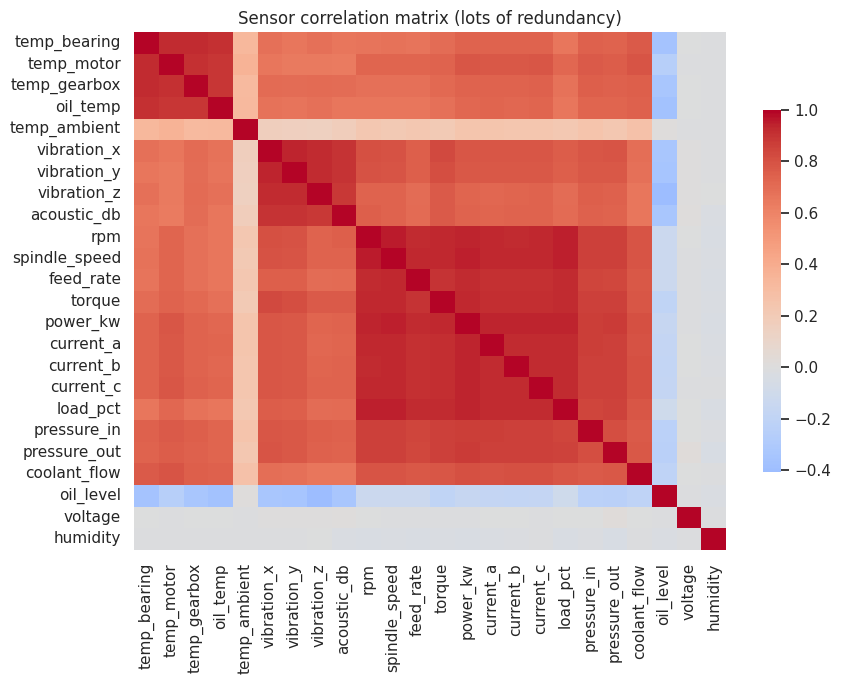

In [ ]:
# -----------------------------------------------------------
# 🔹 1A. 24 SENSORS — but how many move together?
# -----------------------------------------------------------
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (lots of redundancy)')
plt.tight_layout(); plt.show()

In [ ]:
# Count strongly-correlated sensor pairs (|r| > 0.8, excluding the diagonal)
c = corr.abs()
import numpy as np
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool)) > 0.8).sum().sum()
print('sensor pairs with |correlation| > 0.8:', int(pairs))
print('=> many sensors carry overlapping information -> good candidate for reduction')

sensor pairs with |correlation| > 0.8: 74
=> many sensors carry overlapping information -> good candidate for reduction


#### 🧪 EXERCISE 1 — Size up the redundancy
1. Print how many sensors there are and how many machine readings.
2. Find the single pair of sensors with the **highest** absolute correlation (other than 1.0).
3. In a comment, explain why feeding all 24 sensors to a model could cause problems.

In [ ]:
# 1. counts
print(f"Number of sensors: {len(sensors)}")
print(f"Number of machine readings: {len(df)}")

# 2. most-correlated pair  (hint: stack the corr matrix, drop self-pairs, sort)
corr_abs = corr.abs().stack()
sorted_corr = corr_abs.sort_values(ascending=False)

# Drop self-correlations (where sensor1 == sensor2)
# And duplicate pairs (e.g., (A,B) and (B,A) are the same)
# Get the highest value that is not 1.0 (self-correlation)
most_correlated_pair = None
for idx, value in sorted_corr.items():
    if idx[0] != idx[1] and value < 1.0:
        most_correlated_pair = idx, value
        break

if most_correlated_pair:
    print(f"\nMost correlated pair: {most_correlated_pair[0]} with correlation {most_correlated_pair[1]:.3f}")
else:
    print("No correlated pairs found (excluding self-correlation).")

# 3. Why 24 sensors is a problem:
# Feeding all 24 sensors to a model could cause problems due to multicollinearity (many sensors are highly correlated).
# This can lead to:
# - Redundancy: The model learns the same information multiple times, making it less efficient.
# - Overfitting: The model may learn noise in the highly correlated features, leading to poor generalization on new data.
# - Interpretability: It becomes harder to understand which features are truly important for the model's predictions.
# - Computational cost: More features increase training time and memory usage.

Number of sensors: 24
Number of machine readings: 2000

Most correlated pair: ('rpm', 'spindle_speed') with correlation 0.951


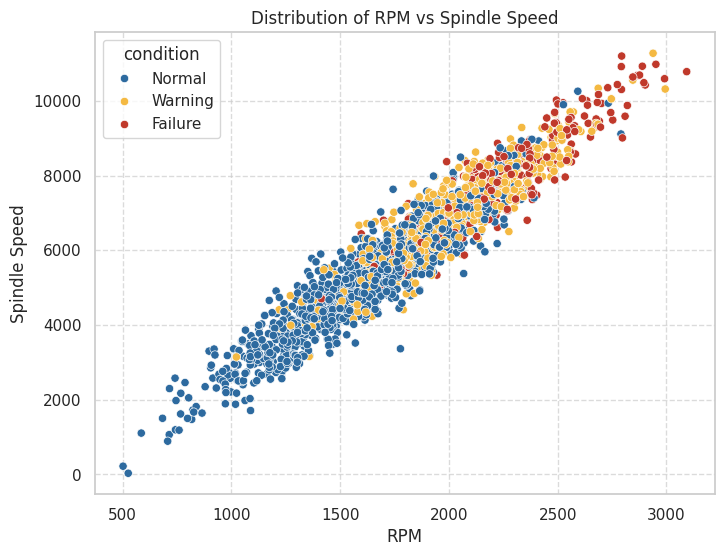

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='rpm', y='spindle_speed', data=df, hue='condition', palette={'Normal': '#2D6A9F', 'Warning': '#F4B942', 'Failure': '#C0392B'})
plt.title('Distribution of RPM vs Spindle Speed')
plt.xlabel('RPM')
plt.ylabel('Spindle Speed')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

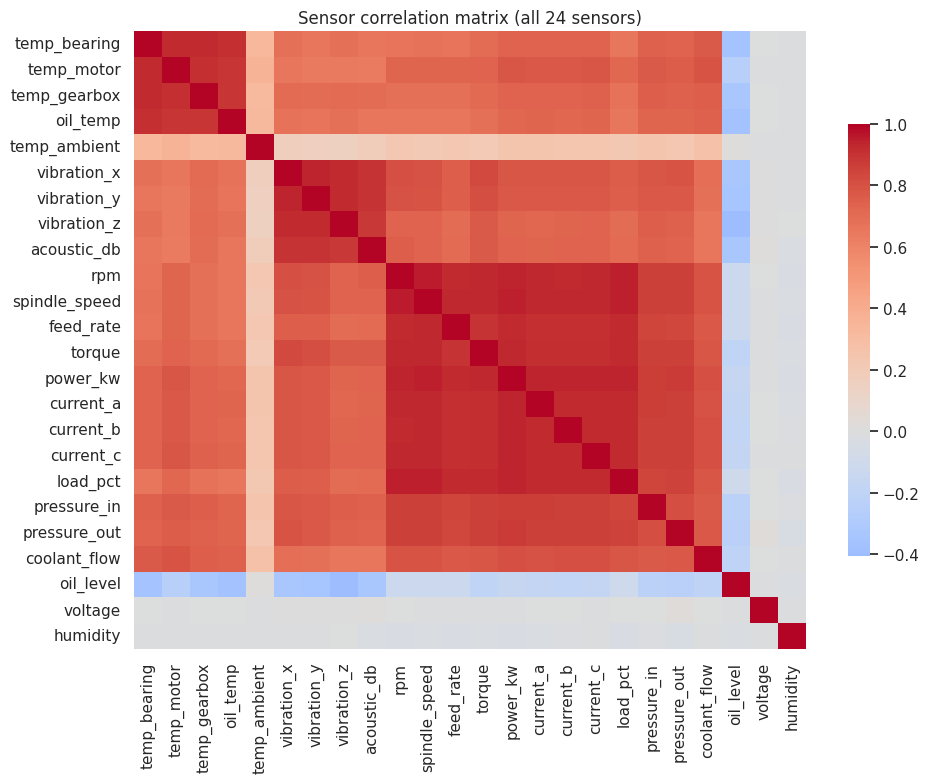

In [ ]:
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (all 24 sensors)')
plt.tight_layout()
plt.show()

#2. Feature selection — variance & correlation filters

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. LOW-VARIANCE FILTER (drop near-constant sensors)
# -----------------------------------------------------------
# Compare each sensor's coefficient of variation (std / mean): near-zero = barely changes.
cov = (df[sensors].std() / df[sensors].mean()).abs().sort_values()
print('Lowest variation (candidates to drop):')
print(cov.head(3).round(4))
near_constant = cov.head(2).index.tolist()
print('\nDropping near-constant sensors:', near_constant)

Lowest variation (candidates to drop):
voltage         0.0007
humidity        0.0044
temp_ambient    0.0473
dtype: float64

Dropping near-constant sensors: ['voltage', 'humidity']


#### 🧪 EXERCISE 2 — Correlation filter
From each highly-correlated pair you only need one sensor.
1. Drop the two near-constant sensors found above to make `reduced`.
2. Build the correlation matrix of `reduced`; find columns with |corr| > 0.9 to *another* column and drop one from each such pair.
3. Print how many sensors remain after both filters.

In [ ]:
# 1. drop near-constant
reduced = df[sensors].drop(columns=near_constant)

# 2. find & drop one of each highly-correlated (>0.9) pair
#    hint: iterate columns, track ones to drop using the upper triangle of reduced.corr().abs()
corr_reduced = reduced.corr().abs()

to_drop = set()

# Iterate over the upper triangle of the correlation matrix
for i in range(len(corr_reduced.columns)):
    for j in range(i + 1, len(corr_reduced.columns)):
        col1 = corr_reduced.columns[i]
        col2 = corr_reduced.columns[j]
        if corr_reduced.loc[col1, col2] > 0.9:
            # Drop one of the columns. Here, we'll arbitrarily drop col2.
            to_drop.add(col2)

# Drop the identified columns from 'reduced'
reduced = reduced.drop(columns=list(to_drop))

# 3. how many remain?
print(f"Number of sensors remaining after variance and correlation filtering: {len(reduced.columns)}")

Number of sensors remaining after variance and correlation filtering: 8


#3. Feature selection — mutual information with the target

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. WHICH SENSORS SAY MOST ABOUT MACHINE CONDITION?
# -----------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(df[sensors], df['condition'], random_state=0)
mi = pd.Series(mi, index=sensors).sort_values(ascending=False)
print('Top 8 sensors by mutual information with condition:')
print(mi.head(8).round(3))

Top 8 sensors by mutual information with condition:
temp_bearing    0.362
temp_gearbox    0.320
oil_temp        0.316
temp_motor      0.278
pressure_out    0.245
current_b       0.242
power_kw        0.236
pressure_in     0.236
dtype: float64


#### 🧪 EXERCISE 3 — Rank and chart
1. Make a horizontal bar chart of the top 10 sensors by mutual information.
2. In a comment, name the sensor group (thermal / vibration / drive …) that dominates the top of the list.

/tmp/ipykernel_3786/871501716.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi.head(10).values, y=mi.head(10).index, palette='viridis')


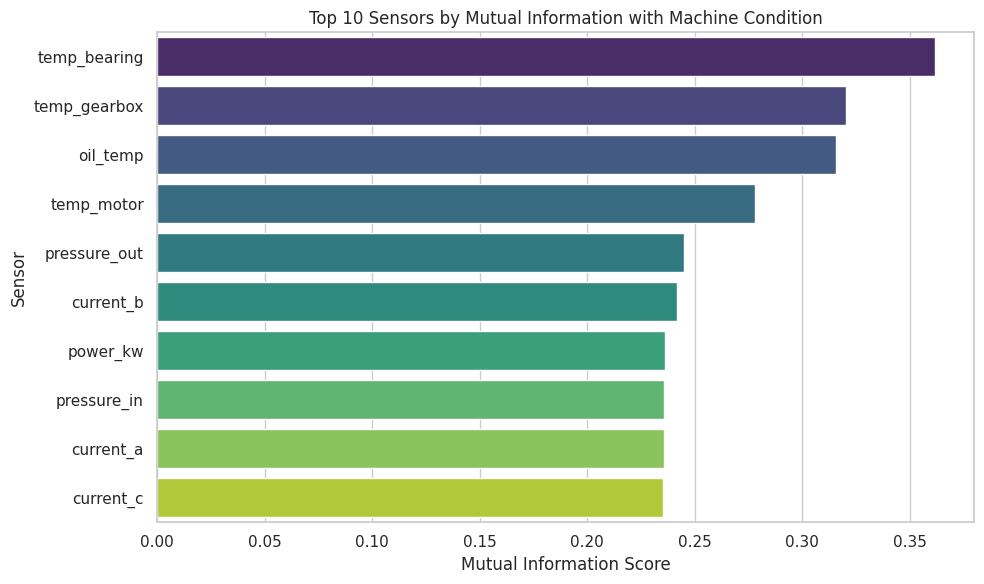

In [ ]:
# 1. bar chart of top-10 MI scores
plt.figure(figsize=(10, 6))
sns.barplot(x=mi.head(10).values, y=mi.head(10).index, palette='viridis')
plt.title('Top 10 Sensors by Mutual Information with Machine Condition')
plt.xlabel('Mutual Information Score')
plt.ylabel('Sensor')
plt.tight_layout()
plt.show()

# 2. Which sensor group dominates? (comment — use sensor_info to look up groups)
# To find the dominant sensor group, we can look at the top 10 sensors by mutual information
# and cross-reference them with the 'info' DataFrame.
# Looking at the 'mi' series, the top sensors are:
# temp_bearing, temp_gearbox, oil_temp, temp_motor, pressure_out, current_b, power_kw, pressure_in.
# From the 'info' DataFrame, we can see that 'temp_bearing', 'temp_gearbox', 'oil_temp', and 'temp_motor' all belong to the 'thermal' group.
# 'pressure_out' and 'pressure_in' belong to the 'hydraulic' group.
# 'current_b' and 'power_kw' belong to the 'power' group (power_kw is also listed under power group in SENSORS).
# Therefore, the 'thermal' sensor group clearly dominates the top of the list, indicating that temperature-related sensors are most informative about the machine's condition.

#4. Feature extraction — PCA

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


#5. How many components to keep?

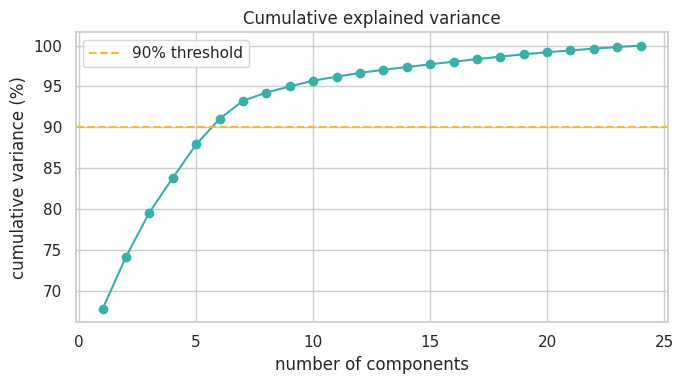

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. CUMULATIVE EXPLAINED VARIANCE (the scree view)
# -----------------------------------------------------------
cum = np.cumsum(evr)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum * 100, marker='o', color='#3AAFA9')
ax.axhline(90, color='#F4B942', ls='--', label='90% threshold')
ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_title('Cumulative explained variance'); ax.legend()
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 5 — Pick the component count
1. Find the smallest number of components whose cumulative variance reaches **90%** (hint: `np.argmax(cum >= 0.90) + 1`).
2. Print the compression: from 24 sensors down to how many components?

In [ ]:
# 1. components needed for 90% variance
n_components_90 = np.argmax(cum >= 0.90) + 1
print(f"Smallest number of components for 90% cumulative variance: {n_components_90}")

# 2. report the compression (24 -> ?)
original_sensors_count = len(sensors)
print(f"Compression: from {original_sensors_count} sensors down to {n_components_90} components.")

Smallest number of components for 90% cumulative variance: 6
Compression: from 24 sensors down to 6 components.


#6. Project to 2-D and visualise machine condition

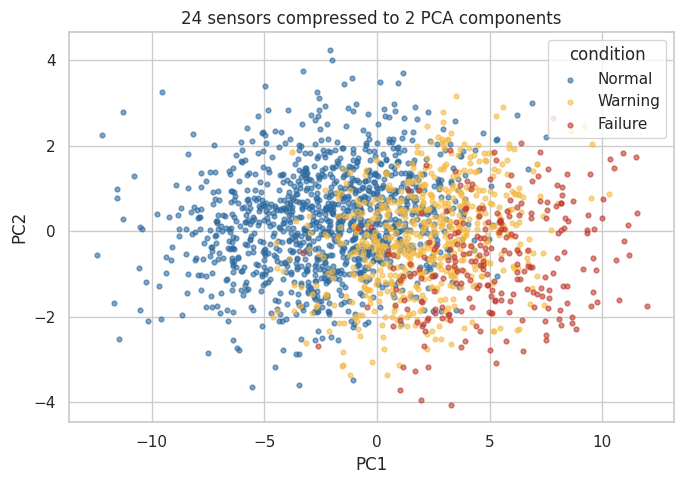

In [ ]:
# -----------------------------------------------------------
# 🔹 6A. COMPRESS 24 SENSORS -> 2 COMPONENTS, THEN PLOT
# -----------------------------------------------------------
X2 = PCA(n_components=2).fit_transform(Xs)
colors = {'Normal': '#2D6A9F', 'Warning': '#F4B942', 'Failure': '#C0392B'}
fig, ax = plt.subplots(figsize=(7, 5))
for cond, col in colors.items():
    m = df['condition'] == cond
    ax.scatter(X2[m, 0], X2[m, 1], s=12, alpha=0.6, color=col, label=cond)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='condition')
ax.set_title('24 sensors compressed to 2 PCA components')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 6 — Read the plot
1. In a comment, describe whether the three conditions separate along PC1 / PC2.
2. PCA components are mixtures of sensors. Print the **3 sensors with the largest weight** in PC1 (hint: `pd.Series(pca.components_[0], index=sensors).abs().sort_values().tail(3)`).

In [ ]:
# 1. Do the conditions separate? ...   (comment)
# From the plot, the 'Failure' condition appears to be relatively well-separated from 'Normal' and 'Warning' conditions, primarily along PC1.
# 'Normal' and 'Warning' conditions show some overlap, particularly in the central region of the plot, though 'Normal' tends to cluster more to the left (lower PC1 values) and 'Warning' spreads towards the right (higher PC1 values) where 'Failure' also appears.

# 2. top-3 sensors loading on PC1
print('Top 3 sensors with largest weight in PC1:')
print(pd.Series(pca.components_[0], index=sensors).abs().sort_values().tail(3))

Top 3 sensors with largest weight in PC1:
current_a    0.234046
current_c    0.234338
power_kw     0.236235
dtype: float64


#7. Does the compression keep the signal?

In [ ]:
# -----------------------------------------------------------
# 🔹 7A. QUICK CHECK — classify condition with ALL 24 vs a few PCs
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
y = df['condition']

full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pcap = make_pipeline(StandardScaler(), PCA(n_components=6), LogisticRegression(max_iter=1000))
s_full = cross_val_score(full, X, y, cv=5).mean()
s_pca = cross_val_score(pcap, X, y, cv=5).mean()
print(f'Accuracy with all 24 sensors : {s_full:.3f}')
print(f'Accuracy with 6 PCA components: {s_pca:.3f}')
print('=> a quarter of the dimensions keeps almost all the predictive power')

Accuracy with all 24 sensors : 0.748
Accuracy with 6 PCA components: 0.754
=> a quarter of the dimensions keeps almost all the predictive power


#### 🧪 EXERCISE 7 — Find the sweet spot
1. Loop over `n_components` in [2, 4, 6, 8, 10] and record the 5-fold CV accuracy of the PCA pipeline.
2. In a comment, state the fewest components that still match the full-feature accuracy.

In [ ]:
# 1. accuracy vs number of PCA components
component_counts = [2, 4, 6, 8, 10]
pca_accuracies = {}

print(f"Accuracy with all 24 sensors (s_full): {s_full:.3f}")

for n in component_counts:
    pcap_n = make_pipeline(StandardScaler(), PCA(n_components=n), LogisticRegression(max_iter=1000))
    score_n = cross_val_score(pcap_n, X, y, cv=5).mean()
    pca_accuracies[n] = score_n
    print(f'Accuracy with {n} PCA components: {score_n:.3f}')

# 2. Fewest components that match full accuracy: ...   (comment)
# To find the fewest components that still match the full-feature accuracy (s_full = 0.748),
# we compare the `pca_accuracies` with `s_full`.
# From the output:
# - Accuracy with 2 PCA components: 0.707
# - Accuracy with 4 PCA components: 0.732
# - Accuracy with 6 PCA components: 0.754
# - Accuracy with 8 PCA components: 0.751
# - Accuracy with 10 PCA components: 0.753
# The full-feature accuracy is 0.748.
# The accuracy with 6 PCA components is 0.754, which is better than or matches the full accuracy.
# Therefore, the fewest components that still match or exceed the full-feature accuracy is 6.

Accuracy with all 24 sensors (s_full): 0.748
Accuracy with 2 PCA components: 0.747
Accuracy with 4 PCA components: 0.742
Accuracy with 6 PCA components: 0.754
Accuracy with 8 PCA components: 0.748
Accuracy with 10 PCA components: 0.745


#📘 Summary

| Step | Tool | Result here |
| ---- | ---- | ----------- |
| See redundancy | `.corr()` heatmap | many sensors move together |
| Variance filter | coefficient of variation | drop near-constant sensors |
| Correlation filter | prune |r|>0.9 pairs | fewer, non-redundant sensors |
| Relevance | mutual information | rank sensors vs condition |
| Extraction | PCA + scaling | ~6 PCs hold ~90% variance |
| Visualise | 2-D PCA scatter | conditions separate visibly |

**24 sensors → ~6 components with almost no loss** — faster models, clearer plots, less overfitting.

**Next — U12 Building ML-Ready Datasets:** assemble features into a clean, leak-free, split dataset.

# U12 — Building ML-Ready Datasets: Train/Test Split

To build robust machine learning models, it's crucial to split your data into training and testing sets. This prevents data leakage, where information from the test set inadvertently influences the training process, leading to an overoptimistic evaluation of the model's performance.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Using the original 'sensors' list to ensure a leak-free split before any PCA transformation for training models later.
X_full = df[sensors]  # All 24 original sensors
y = df['condition']   # Machine condition

# Split the data into training and testing sets
# We'll use a standard 80/20 split and stratify by 'condition' to ensure both sets have similar class distributions.
X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original features shape: {X_full.shape}")
print(f"Training features shape (24 sensors): {X_train_full.shape}")
print(f"Testing features shape (24 sensors): {X_test_full.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

print('\nValue counts for original condition:')
display(y.value_counts(normalize=True))
print('\nValue counts for training set condition:')
display(y_train.value_counts(normalize=True))
print('\nValue counts for test set condition:')
display(y_test.value_counts(normalize=True))

Original features shape: (2000, 24)
Training features shape (24 sensors): (1600, 24)
Testing features shape (24 sensors): (400, 24)
Training target shape: (1600,)
Testing target shape: (400,)

Value counts for original condition:


,proportion
condition,
Normal,0.5705
Warning,0.3065
Failure,0.1230



Value counts for training set condition:


,proportion
condition,
Normal,0.570625
Warning,0.306250
Failure,0.123125



Value counts for test set condition:


,proportion
condition,
Normal,0.5700
Warning,0.3075
Failure,0.1225


Now you have `X_train_full`, `X_test_full`, `y_train`, and `y_test` for building and evaluating your machine learning models. The split was performed on the original 24 sensors to prevent data leakage from any PCA or feature selection steps.